# Part 3 Strategy Development and Optimization

Basic structure of the strategy weight allocation is as follows:
$$weight = base \times value \ score \times trend \ score \times accel \ score \times ml1 \ score \times ml2 \ score \times volatility \ score $$

* valuation_score: combine three different valuation signals and get the exponential. This means positive signal will have exponentially larger signal.

$$
v = v_1(\text{MVRV Z-score}) + v_2(\text{price\_vs\_ma}) + v_3(\text{RSI Z-score}), \quad \text{where } v_1 + v_2 + v_3 = 1
$$

$$
\text{valuation\_score} = \exp\left(\text{clip}(v, -v_{lim}, v_{lim})\right)
$$
* grad_score: regime dependent, adjustment is linear to the MVRV Z-score gradient.
$$
g =
\begin{cases}
1 + g_1 \cdot \min(\text{MVRV Z-score grad}, 1), & \text{if MVRV Z-score} > 1.5 \\
1, & \text{otherwise} \\
1 + g_2 \cdot \max(\text{MVRV Z-score grad}, -1), & \text{if MVRV Z-score} < -1
\end{cases}
$$

$$
\text{grad\_score} = \exp\left(\text{clip}(g, g_{\min}, g_{\max})\right)
$$

* accel_score: increase weightage if gradient and acceleration have the same sign, vice versa.

$$
a =
\begin{cases}
1 + a_1 \cdot \left| \text{MVRV Z-score accel} \right|, & \text{if accel and grad have the same sign} \\
1 - a_2 \cdot \left| \text{MVRV Z-score accel} \right|, & \text{if accel and grad have opposite signs}
\end{cases}
$$

$$
\text{accel\_score} = \exp\left(\text{clip}(a, a_{\min}, a_{\max})\right)
$$


* ml1_score: increase multiplier if prob_top30 Z-score is above a certain threshold.

$$
\text{ml1\_score} = 1 + \frac{m_1}{1.5} \cdot \text{clip}(\text{prob\_top30 Z-score}, 0.5, 2)
$$

* ml2_score: decrease multiplier if pred_future_60d_min_rel is below a certain threshold.

$$
\text{ml2\_score} = 1 - \frac{m_2}{0.2} \cdot \text{clip}(\text{pred\_future\_60d\_min\_rel}, -0.4, -0.2)
$$

* risk_score: reduces allocation if high price or MVRV volatility.
$$
r = -r_1(\text{log price volatility Z-score}) - r_2(\text{MVRV volatility Z-score})
$$

$$
\text{risk\_score} = 1 - \frac{r_3}{2} \cdot \text{clip}(r, -3, -1)
$$

Import libraries and load data

In [14]:
import numpy as np
import pandas as pd
import optuna
from typing import Dict, Any, Callable, Optional
import logging
from pathlib import Path
from template.prelude_template import compute_cycle_spd
from template.prelude_template import load_data
from final.model_v2 import precompute_features, compute_window_weights, allocate_sequential_stable
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from IPython.display import SVG, display


In [4]:
btc_df = load_data()
features_df = precompute_features(btc_df)

2026-04-15 15:07:46 INFO     Loading CoinMetrics BTC data from local file: C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\data\Coin Metrics\coinmetrics_btc.csv
2026-04-15 15:07:46 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-04-15 15:07:46 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14


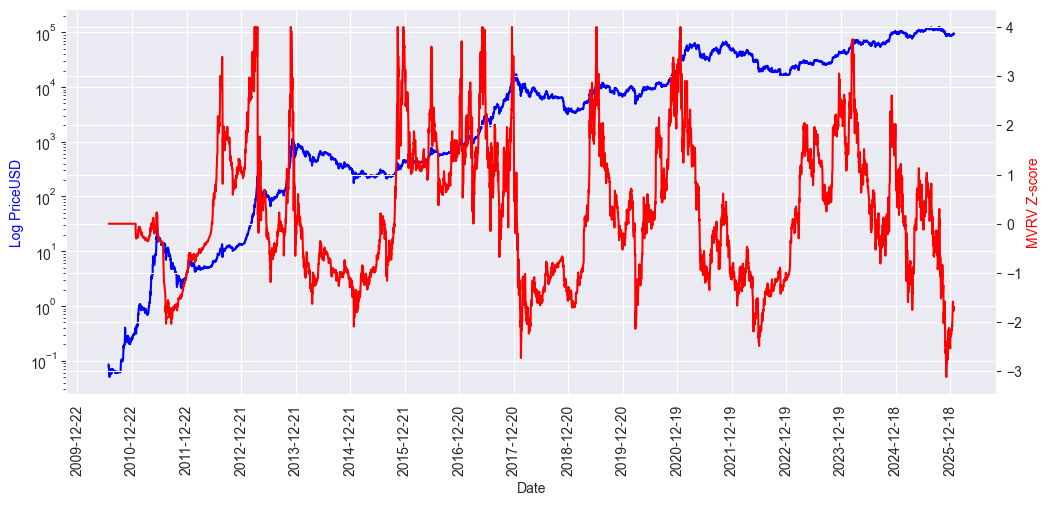

In [58]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# First plot (Left Y-axis)
ax1.semilogy(features_df.index, features_df.PriceUSD_coinmetrics, color='blue')

# Create secondary Y-axis (Right Y-axis)
ax2 = ax1.twinx()
ax2.plot(features_df.index, features_df.oc_MVRVCur_Z, color='red')

ax1.xaxis.set_major_locator(MultipleLocator(365))
ax1.set_ylabel('Log PriceUSD', color='blue')
ax2.set_ylabel('MVRV Z-score', color='red')
ax1.set_xlabel('Date')
plt.grid(True)
ax1.tick_params(axis='x', labelrotation=90)

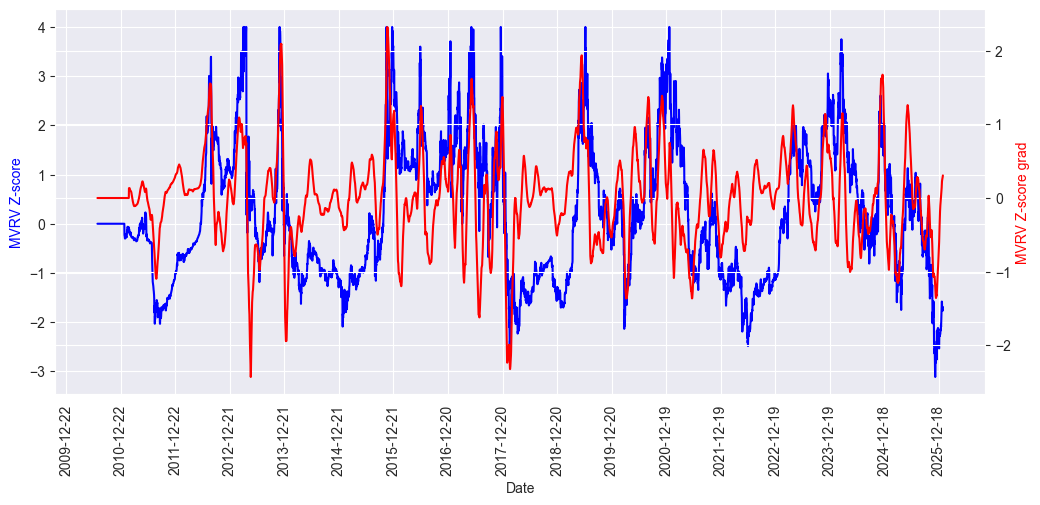

In [52]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# First plot (Left Y-axis)
ax1.plot(features_df.index, features_df.oc_MVRVCur_Z, color='blue')

# Create secondary Y-axis (Right Y-axis)
ax2 = ax1.twinx()
ax2.plot(features_df.index, features_df.oc_MVRVCur_grad, color='red')

ax1.xaxis.set_major_locator(MultipleLocator(365))
ax1.set_ylabel('MVRV Z-score', color='blue')
ax2.set_ylabel('MVRV Z-score grad')
ax1.set_xlabel('Date')
plt.grid(True)
ax1.tick_params(axis='x', labelrotation=90)

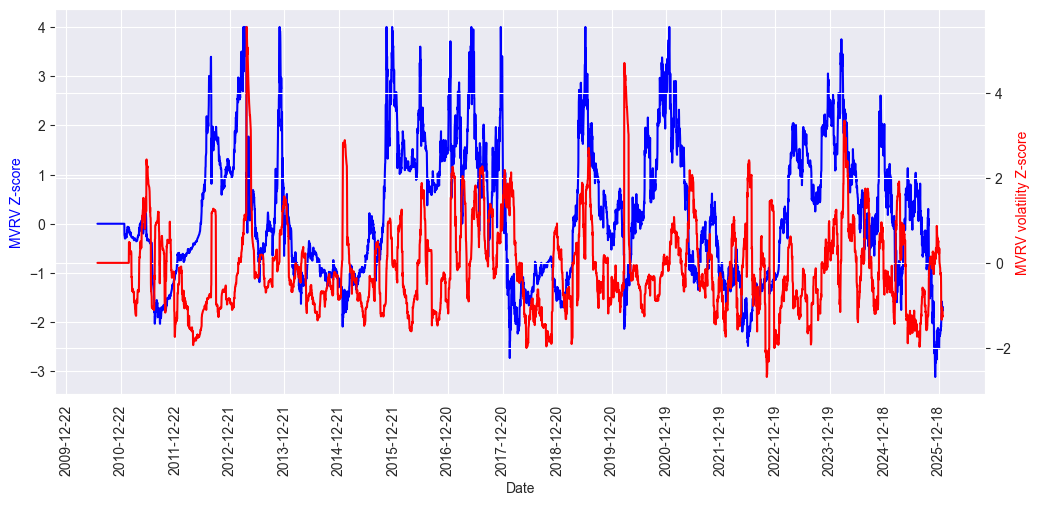

In [62]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# First plot (Left Y-axis)
ax1.plot(features_df.index, features_df.oc_MVRVCur_Z, color='blue')

# Create secondary Y-axis (Right Y-axis)
ax2 = ax1.twinx()
ax2.plot(features_df.index, features_df.oc_MVRVCur_vol_Z, color='red')

ax1.xaxis.set_major_locator(MultipleLocator(365))
ax1.set_ylabel('MVRV Z-score', color='blue')
ax2.set_ylabel('MVRV volatility Z-score', color='red')
ax1.set_xlabel('Date')
plt.grid(True)
ax1.tick_params(axis='x', labelrotation=90)

In [19]:
# =========================================================
# 1. Strategy

def _safe_zscore(series: pd.Series, clip: float = 5.0) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    mu = s.mean()
    sigma = s.std(ddof=0)

    if pd.isna(sigma) or sigma < 1e-12:
        z = pd.Series(0.0, index=s.index)
    else:
        z = (s - mu) / sigma

    return z.clip(-clip, clip).fillna(0.0)

def _clean_array(arr: np.ndarray) -> np.ndarray:
    """Replace NaN/Inf with 0."""
    return np.where(np.isfinite(arr), arr, 0)

def build_strategy_function(params: Dict[str, float]) -> Callable:
    """
    Returns a strategy function compatible with compute_cycle_spd().

    - input: features_df slice/ full DataFrame
    - output: Series /array of dynamic DCA multipliers
    """

    def compute_value_multiplier(oc_MVRVCur_Z, price_vs_ma, RSI_zscore) -> np.ndarray:
        """Compute weight multiplier

        Returns:
            Multipliers centered around 1.0
        """
        # Signal: negative price_vs_ma = below MA = buy more
        w_sum = params["w_val_mvrv"] + params["w_val_pma"] + params["w_val_rsi"]
        w_val_mvrv = params["w_val_mvrv"]/w_sum
        w_val_pma = params["w_val_pma"]/w_sum
        w_val_rsi = params["w_val_rsi"]/w_sum

        signal = -(
                w_val_mvrv * oc_MVRVCur_Z
                + w_val_pma * price_vs_ma
                + w_val_rsi * RSI_zscore
            ) * params["W_val"]

        # Scale and clip

        adjustment = np.clip(signal, -params["val_range"], params["val_range"])

        multiplier = np.exp(adjustment)
        return np.where(np.isfinite(multiplier), multiplier, 1.0)

    def trend_modifier(oc_MVRVCur_Z, oc_MVRVCur_grad):
        threshold = np.where(
            oc_MVRVCur_Z < -1, 0.1,
            np.where(oc_MVRVCur_Z > 1.5, 0.4, 0.2)
        )
        modifier = np.where(
            oc_MVRVCur_grad > threshold, 1.0 + params['w_grad1'] * np.minimum(oc_MVRVCur_grad, 1.0),
            np.where(oc_MVRVCur_grad < -threshold, 1.0 + params['w_grad2'] * np.maximum(oc_MVRVCur_grad, -1.0), 1.0)
        )

        return np.clip(modifier, params['w_grad_min'], params['w_grad_max'])

    def accel_modifier(oc_MVRVCur_grad, oc_MVRVCur_accel):
        same_direction = (oc_MVRVCur_grad * oc_MVRVCur_accel) > 0

        modifier = np.where(
            same_direction,
            1.0 + params['w_accel1'] * np.abs(oc_MVRVCur_accel),  # Amplify if momentum building
            1.0 - params['w_accel2'] * np.abs(oc_MVRVCur_accel)  # Dampen if potential reversal
        )
        return np.clip(modifier, params['w_accel_min'], params['w_accel_max'])

    def compute_risk_score(oc_vol_30d_zscore, oc_MVRVCur_vol_Z):
        w_sum = params["w_risk_price_vol"] + params["w_risk_mvrv_vol"]
        w_risk_price_vol = params["w_risk_price_vol"] / w_sum
        w_risk_mvrv_vol = params["w_risk_mvrv_vol"] / w_sum
        signal = -(w_risk_price_vol * oc_vol_30d_zscore + w_risk_mvrv_vol * oc_MVRVCur_vol_Z)
        multiplier = (np.clip(signal, -3, -1) + 1) * params["W_risk"] / 2 + 1
        return multiplier


    def strategy_function(features_df: pd.DataFrame) -> pd.Series:
        df = features_df.copy()

        required_cols = [
            "oc_MVRVCur_Z",
            "oc_MVRVCur_grad",
            "oc_MVRVCur_accel",
            "price_vs_ma",
            "RSI_zscore",
            "oc_MVRVCur_vol_Z",
            "oc_vol_30d_Z",
            "prob_top30_zscore",
            "min_ratio_log_pred",
            "PriceUSD_coinmetrics",
        ]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Missing required strategy columns: {missing}")

        # Feature transforms

        # Valuation features
        oc_MVRVCur_Z = pd.Series(_clean_array(df["oc_MVRVCur_Z"].to_numpy()), index=df.index)
        price_vs_ma = _clean_array(df["price_vs_ma"].values)
        RSI_zscore = _safe_zscore(df["RSI_zscore"])

        # Timing features
        oc_MVRVCur_grad = _clean_array(df["oc_MVRVCur_grad"].values)
        oc_MVRVCur_accel = _clean_array(df["oc_MVRVCur_accel"].values)

        # ML features
        prob_top30_zscore = _clean_array(df["prob_top30_zscore"].values)
        min_ratio_log_pred = _clean_array(df["min_ratio_log_pred"].values)

        # Risk features
        oc_MVRVCur_vol_Z = _clean_array(df["oc_MVRVCur_vol_Z"].values)
        oc_vol_30d_zscore = _clean_array(df["oc_vol_30d_Z"].values)

        # Compute dynamic weights
        valuation_score = compute_value_multiplier(oc_MVRVCur_Z, price_vs_ma, RSI_zscore)

        grad_score = trend_modifier(oc_MVRVCur_Z, oc_MVRVCur_grad)
        accel_score = accel_modifier(oc_MVRVCur_grad, oc_MVRVCur_accel)

        ml1_score = (
                (np.clip(prob_top30_zscore, 0.5, 2) - 0.5) * params["w_ml_prob70"] / 1.5 + 1
        )

        ml2_score = (
                (np.clip(min_ratio_log_pred, -0.4, -0.1) + 0.1) * params["w_ml_min_gap"] / 0.3 + 1
        )

        risk_score = compute_risk_score(oc_vol_30d_zscore, oc_MVRVCur_vol_Z)

        # Combine scores
        multiplier = (
            valuation_score * grad_score * accel_score * ml1_score * ml2_score * risk_score
        )
        multiplier = pd.Series(allocate_sequential_stable(multiplier, len(df)), index=df.index)

        return multiplier

    return strategy_function


# =========================================================
# 2. Objective scoring

def compute_score(
    spd_table
) -> Dict[str, float]:

    required_cols = ["dynamic_sats_per_dollar", "dynamic_percentile", "uniform_percentile"]
    missing = [c for c in required_cols if c not in spd_table.columns]
    if missing:
        raise ValueError(f"Missing SPD columns: {missing}")

    dynamic_spd = spd_table["dynamic_sats_per_dollar"]
    dynamic_pct = spd_table["dynamic_percentile"]

    # Exponential decay weighting (recent windows weighted more)
    N = len(dynamic_spd)
    exp_weights = 0.9 ** np.arange(N - 1, -1, -1)
    exp_weights /= exp_weights.sum()
    exp_decay_percentile = (dynamic_pct.values * exp_weights).sum()

    win_rate = (
        spd_table["dynamic_percentile"] > spd_table["uniform_percentile"]
    ).mean() * 100
    score = 0.5 * win_rate + 0.5 * exp_decay_percentile

    return {
        "score": score,
        "win_rate": win_rate,
        "exp_decay_percentile": exp_decay_percentile
    }

# =========================================================
# 3. Optuna parameter search space

def suggest_params(trial: optuna.Trial) -> Dict[str, float]:
    params = {
        "w_val_mvrv": trial.suggest_float("w_val_mvrv", 0.0, 1.0),
        "w_val_pma": trial.suggest_float("w_val_pma", 0.0, 0.5),
        "w_val_rsi": trial.suggest_float("w_val_rsi", 0.0, 0.5),
        "W_val": trial.suggest_float("W_val", 0.0, 5.0),
        "val_range": trial.suggest_float("val_range", 20.0, 20.0),

        "w_grad1": trial.suggest_float("w_grad1", 0.1, 1.0),
        "w_grad2": trial.suggest_float("w_grad2", 0.1, 0.5),
        "w_grad_min": trial.suggest_float("w_grad_min", 0.7, 1.0),
        "w_grad_max": trial.suggest_float("w_grad_max", 1.0, 1.5),

        "w_accel1": trial.suggest_float("w_accel1", 0.0, 1.0),
        "w_accel2": trial.suggest_float("w_accel2", 0.0, 0.5),
        "w_accel_min": trial.suggest_float("w_accel_min", 0.7, 1.0),
        "w_accel_max": trial.suggest_float("w_accel_max", 1.0, 1.5),

        "w_ml_prob70": trial.suggest_float("w_ml_prob70", 0.0, 0.5),
        "w_ml_min_gap": trial.suggest_float("w_ml_min_gap", 0.0, 0.5),

        "w_risk_price_vol": trial.suggest_float("w_risk_price_vol", 0.0, 1.0),
        "w_risk_mvrv_vol": trial.suggest_float("w_risk_mvrv_vol", 0.0, 1.0),

        "W_risk": trial.suggest_float("W_risk", 0.0, 0.5),
    }
    return params


# =========================================================
# 4. Objective factory

def objective_factory(
    dataframe: pd.DataFrame,
    features_df: pd.DataFrame,
    compute_cycle_spd: Callable[..., pd.DataFrame],
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
):

    def objective(trial: optuna.Trial) -> float:
        params = suggest_params(trial)

        strategy_function = build_strategy_function(params)

        # Inspect multiplier on provided features_df
        try:
            mult = strategy_function(features_df)
        except Exception as e:
            trial.set_user_attr("error", f"strategy_function failed: {repr(e)}")
            return -1e9

        mult = pd.to_numeric(mult, errors="coerce")
        if mult.isna().all():
            return -1e9

        # Main SPD evaluation
        try:
            spd_table = compute_cycle_spd(
                dataframe,
                strategy_function,
                features_df=features_df,
                start_date=start_date,
                end_date=end_date,
            )
        except Exception as e:
            trial.set_user_attr("error", f"compute_cycle_spd failed: {repr(e)}")
            return -1e9

        stats = compute_score(
            spd_table
        )

        if not np.isfinite(stats["score"]):
            return -1e9

        final_score = stats["score"]
        trial.set_user_attr("final_score", final_score)

        return float(final_score)

    return objective


# =========================================================
# 5. Optimization

def optimize_dynamic_dca_strategy(
    dataframe: pd.DataFrame,
    features_df: pd.DataFrame,
    compute_cycle_spd: Callable[..., pd.DataFrame],
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    n_trials: int = 300,
    study_name: str = "btc_dynamic_dca_spd_opt",
    storage: Optional[str] = None,
    seed: int = 42,
) -> optuna.Study:
    sampler = optuna.samplers.TPESampler(seed=seed)

    study = optuna.create_study(
        direction="maximize",
        study_name=study_name,
        sampler=sampler,
        storage=storage,
        load_if_exists=bool(storage),
    )

    objective = objective_factory(
        dataframe=dataframe,
        features_df=features_df,
        compute_cycle_spd=compute_cycle_spd,
        start_date=start_date,
        end_date=end_date,
    )

    study.optimize(objective, n_trials=n_trials)
    return study


# =========================================================
# 6. Post-optimization inspection

def evaluate_best_strategy(
    study: optuna.Study,
    dataframe: pd.DataFrame,
    features_df: pd.DataFrame,
    compute_cycle_spd: Callable[..., pd.DataFrame],
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
) -> Dict[str, Any]:
    best_params = study.best_params
    strategy_function = build_strategy_function(best_params)

    multiplier = strategy_function(features_df)

    spd_table = compute_cycle_spd(
        dataframe,
        strategy_function,
        features_df=features_df,
        start_date=start_date,
        end_date=end_date,
    )

    stats = compute_score(
        spd_table
    )

    return {
        "best_params": best_params,
        "multiplier_summary": {
            "mean": float(pd.to_numeric(multiplier, errors="coerce").mean()),
            "std": float(pd.to_numeric(multiplier, errors="coerce").std(ddof=0)),
            "min": float(pd.to_numeric(multiplier, errors="coerce").min()),
            "max": float(pd.to_numeric(multiplier, errors="coerce").max()),
        },
        "spd_stats": stats,
        "spd_table": spd_table,
        "multiplier_series": multiplier,
    }


In [5]:
# =========================================================
# 1. Strategy

def _safe_zscore(series: pd.Series, clip: float = 5.0) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    mu = s.mean()
    sigma = s.std(ddof=0)

    if pd.isna(sigma) or sigma < 1e-12:
        z = pd.Series(0.0, index=s.index)
    else:
        z = (s - mu) / sigma

    return z.clip(-clip, clip).fillna(0.0)

def _clean_array(arr: np.ndarray) -> np.ndarray:
    """Replace NaN/Inf with 0."""
    return np.where(np.isfinite(arr), arr, 0)

def build_strategy_function(params: Dict[str, float]) -> Callable:
    """
    Returns a strategy function compatible with compute_cycle_spd().

    - input: features_df slice/ full DataFrame
    - output: Series /array of dynamic DCA multipliers
    """

    def compute_value_multiplier(oc_MVRVCur_Z, price_vs_ma, RSI_zscore) -> np.ndarray:
        """Compute weight multiplier

        Returns:
            Multipliers centered around 1.0
        """
        # Signal: negative price_vs_ma = below MA = buy more
        w_sum = params["w_val_mvrv"] + params["w_val_pma"] + params["w_val_rsi"]
        w_val_mvrv = params["w_val_mvrv"]/w_sum
        w_val_pma = params["w_val_pma"]/w_sum
        w_val_rsi = params["w_val_rsi"]/w_sum

        signal = -(
                w_val_mvrv * oc_MVRVCur_Z
                + w_val_pma * price_vs_ma
                + w_val_rsi * RSI_zscore
            ) * params["W_val"]

        # Scale and clip

        adjustment = np.clip(signal, -params["val_range"], params["val_range"])

        multiplier = np.exp(adjustment)
        return np.where(np.isfinite(multiplier), multiplier, 1.0)

    def trend_modifier(oc_MVRVCur_Z, oc_MVRVCur_grad):
        threshold = np.where(
            oc_MVRVCur_Z < -1, 0.1,
            np.where(oc_MVRVCur_Z > 1.5, 0.4, 0.2)
        )
        modifier = np.where(
            oc_MVRVCur_grad > threshold, 1.0 + params['w_grad1'] * np.minimum(oc_MVRVCur_grad, 1.0),
            np.where(oc_MVRVCur_grad < -threshold, 1.0 + params['w_grad2'] * np.maximum(oc_MVRVCur_grad, -1.0), 1.0)
        )

        return np.clip(modifier, params['w_grad_min'], params['w_grad_max'])

    def accel_modifier(oc_MVRVCur_grad, oc_MVRVCur_accel):
        same_direction = (oc_MVRVCur_grad * oc_MVRVCur_accel) > 0

        modifier = np.where(
            same_direction,
            1.0 + params['w_accel1'] * np.abs(oc_MVRVCur_accel),  # Amplify if momentum building
            1.0 - params['w_accel2'] * np.abs(oc_MVRVCur_accel)  # Dampen if potential reversal
        )
        return np.clip(modifier, params['w_accel_min'], params['w_accel_max'])

    def compute_risk_score(oc_vol_30d_zscore, oc_MVRVCur_vol_Z):
        w_sum = params["w_risk_price_vol"] + params["w_risk_mvrv_vol"]
        w_risk_price_vol = params["w_risk_price_vol"] / w_sum
        w_risk_mvrv_vol = params["w_risk_mvrv_vol"] / w_sum
        signal = -(w_risk_price_vol * oc_vol_30d_zscore + w_risk_mvrv_vol * oc_MVRVCur_vol_Z)
        multiplier = (np.clip(signal, -3, -1) + 1) * params["W_risk"] / 2 + 1
        return multiplier


    def strategy_function(features_df: pd.DataFrame) -> pd.Series:
        df = features_df.copy()

        required_cols = [
            "oc_MVRVCur_Z",
            "oc_MVRVCur_grad",
            "oc_MVRVCur_accel",
            "price_vs_ma",
            "RSI_zscore",
            "oc_MVRVCur_vol_Z",
            "oc_vol_30d_Z",
            "prob_top30_zscore",
            "min_ratio_log_pred",
            "PriceUSD_coinmetrics",
        ]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Missing required strategy columns: {missing}")

        # Feature transforms

        # Valuation features
        oc_MVRVCur_Z = pd.Series(_clean_array(df["oc_MVRVCur_Z"].to_numpy()), index=df.index)
        price_vs_ma = _clean_array(df["price_vs_ma"].values)
        RSI_zscore = _safe_zscore(df["RSI_zscore"])

        # Timing features
        oc_MVRVCur_grad = _clean_array(df["oc_MVRVCur_grad"].values)
        oc_MVRVCur_accel = _clean_array(df["oc_MVRVCur_accel"].values)

        # ML features
        prob_top30_zscore = _clean_array(df["prob_top30_zscore"].values)
        min_ratio_log_pred = _clean_array(df["min_ratio_log_pred"].values)

        # Risk features
        oc_MVRVCur_vol_Z = _clean_array(df["oc_MVRVCur_vol_Z"].values)
        oc_vol_30d_zscore = _clean_array(df["oc_vol_30d_Z"].values)

        # Compute dynamic weights
        valuation_score = compute_value_multiplier(oc_MVRVCur_Z, price_vs_ma, RSI_zscore)

        grad_score = trend_modifier(oc_MVRVCur_Z, oc_MVRVCur_grad)
        accel_score = accel_modifier(oc_MVRVCur_grad, oc_MVRVCur_accel)

        ml1_score = (
                (np.clip(prob_top30_zscore, 0.5, 2) - 0.5) * params["w_ml_prob70"] / 1.5 + 1
        )

        ml2_score = (
                (np.clip(min_ratio_log_pred, -0.4, -0.1) + 0.1) * params["w_ml_min_gap"] / 0.3 + 1
        )

        risk_score = compute_risk_score(oc_vol_30d_zscore, oc_MVRVCur_vol_Z)

        # Combine scores
        multiplier = (
            valuation_score * grad_score * accel_score * ml1_score * ml2_score * risk_score
        )
        multiplier = pd.Series(allocate_sequential_stable(multiplier, len(df)), index=df.index)

        return multiplier

    return strategy_function


# =========================================================
# 2. Objective scoring

def compute_score(
    spd_table
) -> Dict[str, float]:

    required_cols = ["dynamic_sats_per_dollar", "dynamic_percentile", "uniform_percentile"]
    missing = [c for c in required_cols if c not in spd_table.columns]
    if missing:
        raise ValueError(f"Missing SPD columns: {missing}")

    dynamic_spd = spd_table["dynamic_sats_per_dollar"]
    dynamic_pct = spd_table["dynamic_percentile"]

    # Exponential decay weighting (recent windows weighted more)
    N = len(dynamic_spd)
    exp_weights = 0.9 ** np.arange(N - 1, -1, -1)
    exp_weights /= exp_weights.sum()
    exp_decay_percentile = (dynamic_pct.values * exp_weights).sum()

    win_rate = (
        spd_table["dynamic_percentile"] > spd_table["uniform_percentile"]
    ).mean() * 100
    score = 0.5 * win_rate + 0.5 * exp_decay_percentile

    return {
        "score": score,
        "win_rate": win_rate,
        "exp_decay_percentile": exp_decay_percentile
    }

# =========================================================
# 3. Optuna parameter search space

def suggest_params(trial: optuna.Trial) -> Dict[str, float]:
    params = {
        "w_val_mvrv": trial.suggest_float("w_val_mvrv", 0.0, 1.0),
        "w_val_pma": trial.suggest_float("w_val_pma", 0.0, 0.5),
        "w_val_rsi": trial.suggest_float("w_val_rsi", 0.0, 0.5),
        "W_val": trial.suggest_float("W_val", 0.0, 5.0),
        "val_range": trial.suggest_float("val_range", 20.0, 20.0),

        "w_grad1": trial.suggest_float("w_grad1", 0.1, 1.0),
        "w_grad2": trial.suggest_float("w_grad2", 0.1, 0.5),
        "w_grad_min": trial.suggest_float("w_grad_min", 0.7, 1.0),
        "w_grad_max": trial.suggest_float("w_grad_max", 1.0, 1.5),

        "w_accel1": trial.suggest_float("w_accel1", 0.0, 1.0),
        "w_accel2": trial.suggest_float("w_accel2", 0.0, 0.5),
        "w_accel_min": trial.suggest_float("w_accel_min", 0.7, 1.0),
        "w_accel_max": trial.suggest_float("w_accel_max", 1.0, 1.5),

        "w_ml_prob70": trial.suggest_float("w_ml_prob70", 0.0, 0.5),
        "w_ml_min_gap": trial.suggest_float("w_ml_min_gap", 0.0, 0.5),

        "w_risk_price_vol": trial.suggest_float("w_risk_price_vol", 0.0, 1.0),
        "w_risk_mvrv_vol": trial.suggest_float("w_risk_mvrv_vol", 0.0, 1.0),

        "W_risk": trial.suggest_float("W_risk", 0.0, 0.5),
    }
    return params


# =========================================================
# 4. Objective factory

def objective_factory(
    dataframe: pd.DataFrame,
    features_df: pd.DataFrame,
    compute_cycle_spd: Callable[..., pd.DataFrame],
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
):

    def objective(trial: optuna.Trial) -> float:
        params = suggest_params(trial)

        strategy_function = build_strategy_function(params)

        # Inspect multiplier on provided features_df
        try:
            mult = strategy_function(features_df)
        except Exception as e:
            trial.set_user_attr("error", f"strategy_function failed: {repr(e)}")
            return -1e9

        mult = pd.to_numeric(mult, errors="coerce")
        if mult.isna().all():
            return -1e9

        # Main SPD evaluation
        try:
            spd_table = compute_cycle_spd(
                dataframe,
                strategy_function,
                features_df=features_df,
                start_date=start_date,
                end_date=end_date,
            )
        except Exception as e:
            trial.set_user_attr("error", f"compute_cycle_spd failed: {repr(e)}")
            return -1e9

        stats = compute_score(
            spd_table
        )

        if not np.isfinite(stats["score"]):
            return -1e9

        final_score = stats["score"]
        trial.set_user_attr("final_score", final_score)

        return float(final_score)

    return objective


# =========================================================
# 5. Optimization

def optimize_dynamic_dca_strategy(
    dataframe: pd.DataFrame,
    features_df: pd.DataFrame,
    compute_cycle_spd: Callable[..., pd.DataFrame],
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    n_trials: int = 300,
    study_name: str = "btc_dynamic_dca_spd_opt",
    storage: Optional[str] = None,
    seed: int = 42,
) -> optuna.Study:
    sampler = optuna.samplers.TPESampler(seed=seed)

    study = optuna.create_study(
        direction="maximize",
        study_name=study_name,
        sampler=sampler,
        storage=storage,
        load_if_exists=bool(storage),
    )

    objective = objective_factory(
        dataframe=dataframe,
        features_df=features_df,
        compute_cycle_spd=compute_cycle_spd,
        start_date=start_date,
        end_date=end_date,
    )

    study.optimize(objective, n_trials=n_trials)
    return study


# =========================================================
# 6. Post-optimization inspection

def evaluate_best_strategy(
    study: optuna.Study,
    dataframe: pd.DataFrame,
    features_df: pd.DataFrame,
    compute_cycle_spd: Callable[..., pd.DataFrame],
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
) -> Dict[str, Any]:
    best_params = study.best_params
    strategy_function = build_strategy_function(best_params)

    multiplier = strategy_function(features_df)

    spd_table = compute_cycle_spd(
        dataframe,
        strategy_function,
        features_df=features_df,
        start_date=start_date,
        end_date=end_date,
    )

    stats = compute_score(
        spd_table
    )

    return {
        "best_params": best_params,
        "multiplier_summary": {
            "mean": float(pd.to_numeric(multiplier, errors="coerce").mean()),
            "std": float(pd.to_numeric(multiplier, errors="coerce").std(ddof=0)),
            "min": float(pd.to_numeric(multiplier, errors="coerce").min()),
            "max": float(pd.to_numeric(multiplier, errors="coerce").max()),
        },
        "spd_stats": stats,
        "spd_table": spd_table,
        "multiplier_series": multiplier,
    }


In [6]:
# Test to ensure model can run
params = suggest_params(optuna.trial.FixedTrial({
    "w_val_mvrv": 0.5,
    "w_val_pma": 0.35,
    "w_val_rsi": 0.15,
    "val_range": 20,
    "w_grad1": 0.5,
    "w_grad2": 0.2,
    "w_grad_min": 0.8,
    "w_grad_max": 1.2,
    "w_accel1": 0.5,
    "w_accel2": 0.5,
    "w_accel_min": 0.9,
    "w_accel_max": 1.1,
    "w_ml_prob70": 0.5,
    "w_ml_min_gap": 0.5,
    "w_risk_price_vol": 0.5,
    "w_risk_mvrv_vol": 0.5,
    "W_val": 3,
    "W_risk": 0.2,
}))
sf = build_strategy_function(params)
mult = pd.Series(sf(features_df), index=features_df.index)
print(type(mult))
print(mult.head())
print(mult.isna().sum())
print(mult.sum())

<class 'pandas.core.series.Series'>
time
2010-07-18    0.00014
2010-07-19    0.00014
2010-07-20    0.00014
2010-07-21    0.00014
2010-07-22    0.00014
Freq: D, dtype: float64
0
1.0


In [20]:
# Start optimization
study = optimize_dynamic_dca_strategy(
    dataframe=btc_df,
    features_df=features_df,
    compute_cycle_spd=compute_cycle_spd,
    start_date="2018-01-01",
    end_date="2025-12-31",
    n_trials=150,
)

[I 2026-04-11 21:05:09,579] A new study created in memory with name: btc_dynamic_dca_spd_opt
2026-04-11 21:05:09 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-04-11 21:05:24 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
[I 2026-04-11 21:05:24,966] Trial 0 finished with value: 56.391316506707824 and parameters: {'w_val_mvrv': 0.3745401188473625, 'w_val_pma': 0.4753571532049581, 'w_val_rsi': 0.36599697090570255, 'W_val': 2.993292420985183, 'val_range': 20.0, 'w_grad1': 0.24041677639819287, 'w_grad2': 0.16239780813448107, 'w_grad_min': 0.7174250836504598, 'w_grad_max': 1.4330880728874675, 'w_accel1': 0.6011150117432088, 'w_accel2': 0.35403628889802274, 'w_accel_min': 0.7061753482887407, 'w_accel_max': 1.484954926080997, 'w_ml_prob70': 0.41622132040021087, 'w_ml_min_gap': 0.10616955533913808, 'w_risk_price_vol': 0.18182496720710062, 'w_risk_mvrv_vol': 0.18340450985343382, 'W_risk': 0.15212112147976886}. Best is trial 0 with value: 

In [26]:
print("Best objective:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(result["spd_stats"])
print(result["multiplier_summary"])

Best objective: 60.398724586425374
Best params:
  w_val_mvrv: 0.7580741558532044
  w_val_pma: 0.4522114540755125
  w_val_rsi: 0.009116793007697986
  W_val: 4.9021983896396515
  val_range: 20.0
  w_grad1: 0.38808897437757395
  w_grad2: 0.3795357058207186
  w_grad_min: 0.7281129589206239
  w_grad_max: 1.4670224770322686
  w_accel1: 0.007218875397044383
  w_accel2: 0.010296215521067471
  w_accel_min: 0.7011512885465969
  w_accel_max: 1.3036004444360998
  w_ml_prob70: 0.32132810909763554
  w_ml_min_gap: 0.03555647237071294
  w_risk_price_vol: 0.635760429352899
  w_risk_mvrv_vol: 0.9239592693631066
  W_risk: 0.05559167039286142
{'score': np.float64(60.398724586425374), 'win_rate': np.float64(63.55103637074697), 'exp_decay_percentile': np.float64(57.24641280210378)}
{'mean': 0.00017667844522968197, 'std': 0.0010226700189512137, 'min': 5.882324463579929e-15, 'max': 0.03505152545783437}


In [12]:
%run run_backtest_v1.py

2026-04-15 15:10:34 INFO     Starting Bitcoin DCA Strategy Analysis
2026-04-15 15:10:34 INFO     Loading CoinMetrics BTC data from local file: C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\data\Coin Metrics\coinmetrics_btc.csv
2026-04-15 15:10:34 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-04-15 15:10:34 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14
2026-04-15 15:10:34 INFO     Precomputing features (including MVRV & Polymarket)...
2026-04-15 15:10:34 INFO     Running SPD backtest for 'Example 1 (Polymarket)'...
2026-04-15 15:10:34 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-04-15 15:10:53 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-04-15 15:10:53 INFO     Aggregated Metrics for Example 1 (Polymarket):
2026-04-15 15:10:53 INFO       SPD: min=1069.48, max=25485.05, mean=7344.53, median=3472.08
2026-04-15 15:10:53 INFO       Perc

Validating strategy submission readiness...


2026-04-15 15:11:20 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-04-15 15:11:41 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)



⚠️ Windows where strategy underperformed Uniform DCA:


,dynamic_percentile,uniform_percentile,Delta
window,,,
2018-01-01 → 2019-01-01,28.968324,34.917062,-5.948739
2018-01-02 → 2019-01-02,29.357585,35.111968,-5.754383
2018-01-03 → 2019-01-03,29.641216,35.322066,-5.680850
2018-01-04 → 2019-01-04,31.278663,35.530215,-4.251552
2018-01-05 → 2019-01-05,33.072512,35.740775,-2.668262
...,...,...,...
2023-11-19 → 2024-11-19,38.340915,39.550931,-1.210016
2023-11-20 → 2024-11-20,39.157433,40.069270,-0.911837
2023-11-21 → 2024-11-21,40.742898,41.422824,-0.679926


2026-04-15 15:11:41 INFO     Final Model Score: 60.16%
2026-04-15 15:11:41 INFO       Excess percentile: mean=5.41%, median=8.23%
2026-04-15 15:11:41 INFO       Relative improvement: mean=15.28%, median=21.32%
2026-04-15 15:11:41 INFO       Ratio (dynamic/uniform): mean=1.15, median=1.21
2026-04-15 15:11:41 INFO     Generating visualizations...



Summary: 954/2557 underperformed (62.69% win rate)
✅ Strategy meets performance requirement (≥ 50% win rate vs. uniform DCA).

✅ Strategy is ready for submission.


2026-04-15 15:11:43 INFO     ✓ Saved: C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\final\output\performance_comparison.svg
2026-04-15 15:11:43 INFO     ✓ Saved: C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\final\output\excess_percentile_distribution.svg
2026-04-15 15:11:43 INFO     ✓ Saved: C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\final\output\win_loss_comparison.svg
2026-04-15 15:11:45 INFO     ✓ Saved: C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\final\output\cumulative_performance.svg
2026-04-15 15:11:45 INFO     ✓ Saved: C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\final\output\metrics_summary.svg
2026-04-15 15:11:47 INFO     ✓ Saved: C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\final\output\metrics.json
2026-04-15 15:11:47 INFO     All outputs saved to 'C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\final\output/' directory


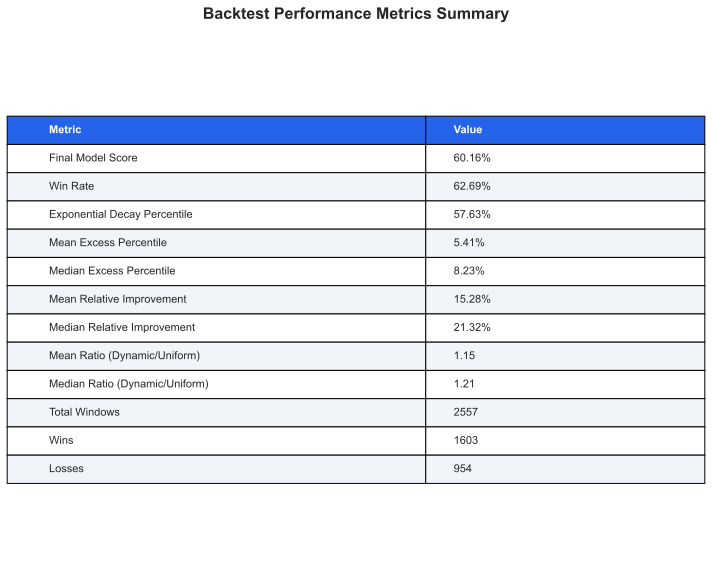

In [16]:
display(SVG(filename='output/metrics_summary.svg'))

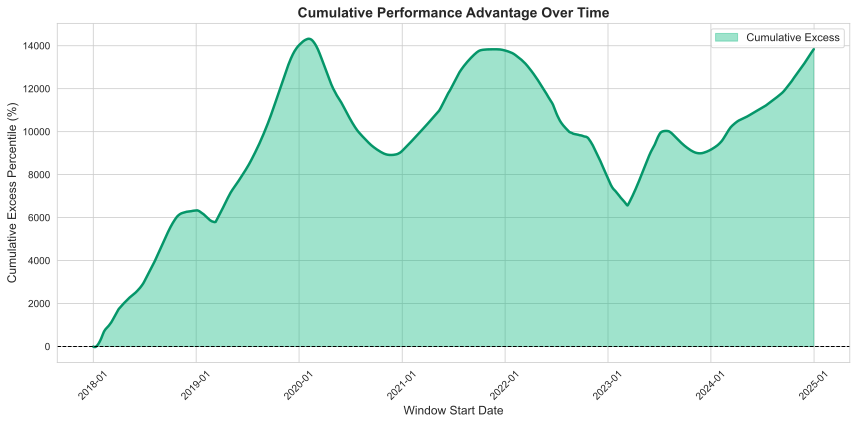

In [17]:
display(SVG(filename='output/cumulative_performance.svg'))

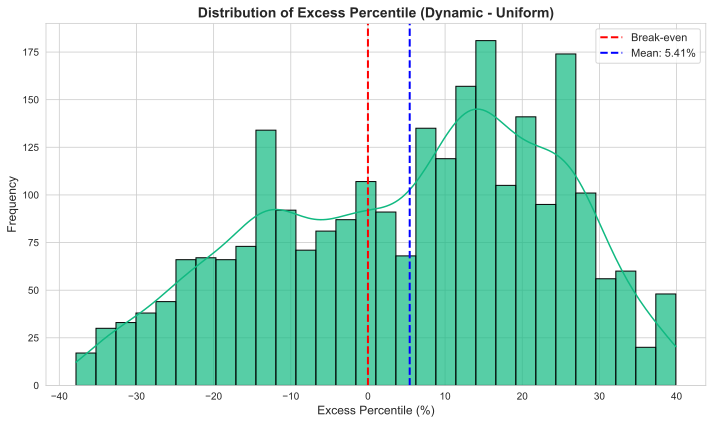

In [18]:
display(SVG(filename='output/excess_percentile_distribution.svg'))

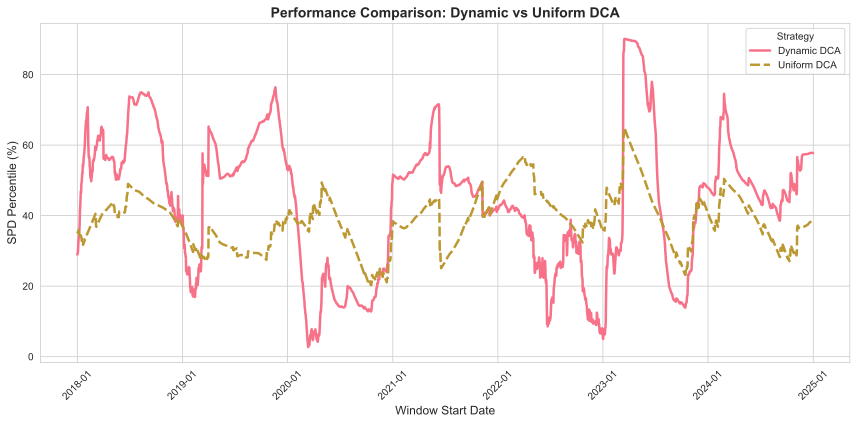

In [19]:
display(SVG(filename='output/performance_comparison.svg'))